In [65]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle

while os.getcwd().split(os.sep)[-1] != "neurolib":
    os.chdir('..')

# We import the model, stimuli, and the optimal control package
from neurolib.models.wc import WCModel
from neurolib.models.aln import ALNModel

from neurolib.utils.stimulus import ZeroInput
from neurolib.control.optimal_control import oc_wc, oc_aln, cost_functions
from neurolib.utils.plot_oc import plot_oc_singlenode

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

datadir = os.path.join("examples", "data")

import matplotlib as mpl

label_size= 20
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 3

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# This function reads out the final state of a simulation
def getfinalstate(model):
    N = model.params.Cmat.shape[0]
    V = len(model.state_vars)
    T = model.getMaxDelay() + 1
    state = np.zeros((N, V, T))
    for v in range(V):
        if "rates" in model.state_vars[v] or "IA" in model.state_vars[v]:
            for n in range(N):
                state[n, v, :] = model.state[model.state_vars[v]][n, -T:]
        else:
            for n in range(N):
                state[n, v, :] = model.state[model.state_vars[v]][n]
    return state

# This function sets the initial state of a model to specific values
def setinitstate(model, state):
    N = model.params.Cmat.shape[0]
    V = len(model.init_vars)
    T = model.getMaxDelay() + 1

    for n in range(N):
        for v in range(V):
            if "rates" in model.init_vars[v] or "IA" in model.init_vars[v]:
                model.params[model.init_vars[v]] = state[:, v, -T:]
            else:
                model.params[model.init_vars[v]] = state[:, v, -1]

    return


# compute the oscillation period of a state trajectory
def getperiod(data, dt):
    maxfreq = []
    for i_d,d in enumerate(data):
        ps = np.abs(np.fft.fft(d))
        ps_ = ps[:int(len(ps)/2)] / (len(ps)/2)
        ps_[0] = 0.
        fr = np.linspace(0,1./(2.*dt),len(ps_))
        maxfreqind = np.where(ps_ == max(ps_[1:]))
        maxfreq.append((1./fr[maxfreqind])[0])

    return np.mean(maxfreq)

[1.9, 1.5]


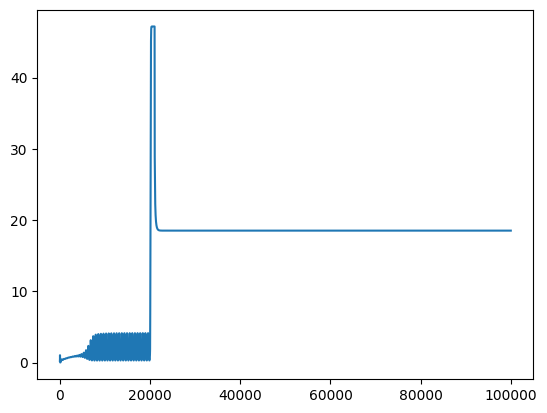

natural period =  58.06322580645162
[1.65627065 1.67784713 1.70058303 1.72331479 1.74603811 1.76874435
 1.79141387 1.81402681 1.83660857 1.85915292]
natural period =  58.06322580645162


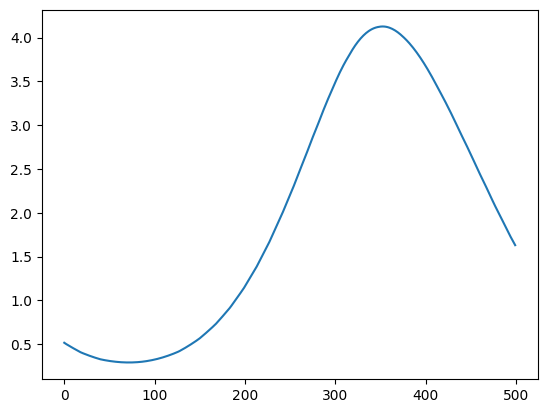

In [25]:
# we set parameters as in the control task discussed in Reference [1] and load the OC computed for the noise-free system
with open(os.path.join(datadir, 'ss_aln.pickle'), 'rb') as f:
    res_read = pickle.load(f)

data = res_read.copy()

N = 1
aln = ALNModel()
dt = aln.params.dt
testd = 1.*1e4
aln.params.duration = testd
aln.params.mue_ext_mean = data["coordinates"][0]
aln.params.mui_ext_mean = data["coordinates"][1]

print(data["coordinates"])

test_input = ZeroInput().generate_input(duration=testd+aln.params.dt, dt=aln.params.dt)
test_input[0,int(2000/dt):int(2100/dt)] = .6
aln.params["ext_exc_current"] = test_input
aln.params["ext_inh_current"] = test_input

aln.run()
plt.plot(aln.rates_exc[0,:])
plt.show()

test_input[0,int(2000/dt):int(2100/dt)] = -0.3

aln.params["ext_exc_current"] = test_input
aln.params["ext_inh_current"] = test_input

aln.run()
plt.plot(aln.rates_exc[0,-500:])

natural_period = getperiod([aln.rates_exc[0,int(1000/dt):]], dt)
print("natural period = ", natural_period)

print(data["init_state"][1][0,0,-10:])

natural_period = getperiod([aln.rates_exc[0,int(1000/dt):]], dt)
print("natural period = ", natural_period)

In [52]:
# hyperparamters of the OC computation
controlmat = np.zeros((1))
controlmat[0] = 1

costmat = np.zeros((1, 3))
costmat[:,0] = 1.

duration = 1000.
int0 = 1000
int1 = 5000
int2 = 6000

max_cntrl = 5
pr = np.arange(0,101,10)

In [27]:
ci = 0 # up to osc task

aln = ALNModel()
setinitstate(aln, data["init_state"][ci])
aln.params["mue_ext_mean"] =  data["coordinates"][0]
aln.params["mui_ext_mean"] =  data["coordinates"][1]
aln.params.duration = duration

aln.run()

aln_controlled = oc_aln.OcAln(aln, natural_period, print_array=pr, cost_interval=(int2,None), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat)
aln_controlled.weights["w_p"] = 0.
aln_controlled.weights["w_2"] = 1.
aln_controlled.weights["w_f_osc"] = data["weights"][ci]

aln_controlled.control = data["control_unshifted"][ci].copy()
aln_controlled.update_input()
aln_controlled.optimize(0)

Optimal control with target oscillation period


IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [ ]:
sigma_array = [7.5 * 1e-3, 15. * 1e-3, 30. * 1e-3]
M_array = [20, 40, 100]

ci = 0

for si, sigma in enumerate(sigma_array):
    aln = ALNModel()
    setinitstate(aln, data["init_state"][ci])
    aln.params["mue_ext_mean"] =  data["coordinates"][0]
    aln.params["mui_ext_mean"] =  data["coordinates"][1]
    aln.params.duration = duration
    aln.params["sigma_ou"] =  sigma

    aln.params["ext_exc_current"] = np.zeros_like(data["control"][ci].copy()[:,0,:])
    aln.run()

    aln_controlled = oc_aln.OcAln(aln, natural_period, print_array=pr, cost_interval=(int2,None), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat, 
                                  M=2, M_validation=400, validate_per_step=True)


    M_array[si] = aln_controlled.find_M(sigma)
    print("M = ", M_array[si])

M_array = [40, 60, 90]

Optimal control with target oscillation period


IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [ ]:
counter_doc = np.zeros((2, 3))
counter_noinput = np.zeros((2, 3))
counter_noc = np.zeros((2, 3, 3))

control_array = [ [[None, None, None], [None, None, None], [None, None, None]],
                  [[None, None, None], [None, None, None], [None, None, None]] ]

In [34]:
with open(os.path.join(datadir, 'data_noisy.pickle'), 'rb') as handle:
    [control_array, counter_noinput, counter_doc, counter_noc] = pickle.load(handle)

print(len(counter_noc))

2


In [53]:
it_av = 1000
M_val = 500
it = 80

for ci in range(2):

    for si, sigma in enumerate(sigma_array):

        if si not in [2]: continue

        aln = ALNModel()
        setinitstate(aln, data["init_state"][ci])
        aln.params["mue_ext_mean"] =  data["coordinates"][0]
        aln.params["mui_ext_mean"] =  data["coordinates"][1]
        aln.params.duration = duration
        aln.params["sigma_ou"] =  sigma

        aln.params["ext_exc_current"] = np.zeros_like(data["control"][ci].copy()[:,0,:])

        for k in range(it_av):
            aln.run()
            if aln.rates_exc[0,-1] < 12:
                counter_noinput[ci, si] += 1

        aln.params["ext_exc_current"] = data["control"][ci].copy()[:,0,:]

        for k in range(it_av):
            aln.run()
            if aln.rates_exc[0,-1] < 12:
                counter_doc[ci, si] += 1

        aln.params["ext_exc_current"] = np.zeros_like(data["control"][ci].copy()[:,0,:])
        aln.run()

        for mi, m in enumerate(M_array):

            aln_controlled = oc_aln.OcAln(aln, natural_period, print_array=pr, cost_interval=(int2,None), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat, 
                                        M=M_array[si], M_validation=M_val, validate_per_step=True
                                        )
            aln_controlled.weights["w_p"] = 0.
            aln_controlled.weights["w_2"] = 1.
            if ci == 0:
                aln_controlled.weights["w_f_osc"] = 1e3
            elif ci == 1:
                aln_controlled.weights["w_f_osc"] = -1.
            aln_controlled.maximum_control_strength = max_cntrl
            aln_controlled.optimize(0)

            for k in [0,4]:
                aln_controlled.zero_step_encountered = False
                aln_controlled.step = 10**(k)
                aln_controlled.optimize(4)

            if ci == 0:
                control_ = aln_controlled.control.copy()
                aln_controlled = oc_aln.OcAln(aln, natural_period, print_array=pr, cost_interval=(int2,None), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat, 
                                        M=M_array[si], M_validation=M_val, validate_per_step=True
                                        )
                aln_controlled.weights["w_p"] = 0.
                aln_controlled.weights["w_2"] = 1.
                aln_controlled.weights["w_f_osc"] = 1e2
                aln_controlled.maximum_control_strength = max_cntrl
                aln_controlled.control = control_.copy()
                aln_controlled.update_input()
                aln_controlled.optimize(0)

            aln_controlled.step = 10**(1)
            aln_controlled.optimize(it)

            control_array[ci][si][mi] = aln_controlled.control.copy()

            plt.plot(aln_controlled.get_xs()[0,0,:])
            plt.show()

            aln.params["ext_exc_current"] = aln_controlled.control.copy()[:,0,:]

            for k in range(it_av):
                aln.run()
                if aln.rates_exc[0,-1] < 12:
                    counter_noc[ci, si, mi] += 1

        with open(os.path.join(datadir, 'data_noisy.pickle'), 'wb') as handle:
            pickle.dump([control_array, counter_noinput, counter_doc, counter_noc], handle)

print(counter_noinput)
print(counter_doc)
print(counter_noc)

Optimal control with target oscillation period


IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [37]:
tex_string = ""

sigma_array = [7.5 * 1e-3, 15. * 1e-3, 30. * 1e-3]
M_array = [4, 12, 36]
it_av = 1000
M_val = 500
it = 80

for si, sigma in enumerate(sigma_array):
    tex_string = tex_string + '{:g}'.format(float('{:.3g}'.format(sigma))) + " & "
    for mi, m in enumerate(M_array):
        tex_string = tex_string + str(m) + " ~~~~"
        for ci in range(2):
            print(si, mi, ci, type(control_array[ci][si][mi]))
            continue
            tex_string = tex_string + " & " + str(int(np.around(100. * counter_noc[ci, si, mi] / it_av, 0)))  + " & " + str(np.around(0.5 * dt * np.sum(control_array[ci][si][mi][0,0,:]**2), 3))
            tex_string = tex_string + " & " + str(int(np.around(100. * counter_doc[ci, si] / it_av, 0)))  + " & " + str(np.around(0.5 * dt * np.sum(data["control"][ci][:,0,:]**2), 3))
        tex_string = tex_string + "\\\\"
        if mi != 2:
            tex_string = tex_string + " & "

print(tex_string)

0 0 0 <class 'numpy.ndarray'>
0 0 1 <class 'NoneType'>
0 1 0 <class 'numpy.ndarray'>
0 1 1 <class 'NoneType'>
0 2 0 <class 'numpy.ndarray'>
0 2 1 <class 'NoneType'>
1 0 0 <class 'numpy.ndarray'>
1 0 1 <class 'NoneType'>
1 1 0 <class 'numpy.ndarray'>
1 1 1 <class 'NoneType'>
1 2 0 <class 'numpy.ndarray'>
1 2 1 <class 'NoneType'>
2 0 0 <class 'NoneType'>
2 0 1 <class 'NoneType'>
2 1 0 <class 'NoneType'>
2 1 1 <class 'NoneType'>
2 2 0 <class 'NoneType'>
2 2 1 <class 'NoneType'>
0.0075 & 4 ~~~~\\ & 12 ~~~~\\ & 36 ~~~~\\0.015 & 4 ~~~~\\ & 12 ~~~~\\ & 36 ~~~~\\0.03 & 4 ~~~~\\ & 12 ~~~~\\ & 36 ~~~~\\


0.0075
0.015


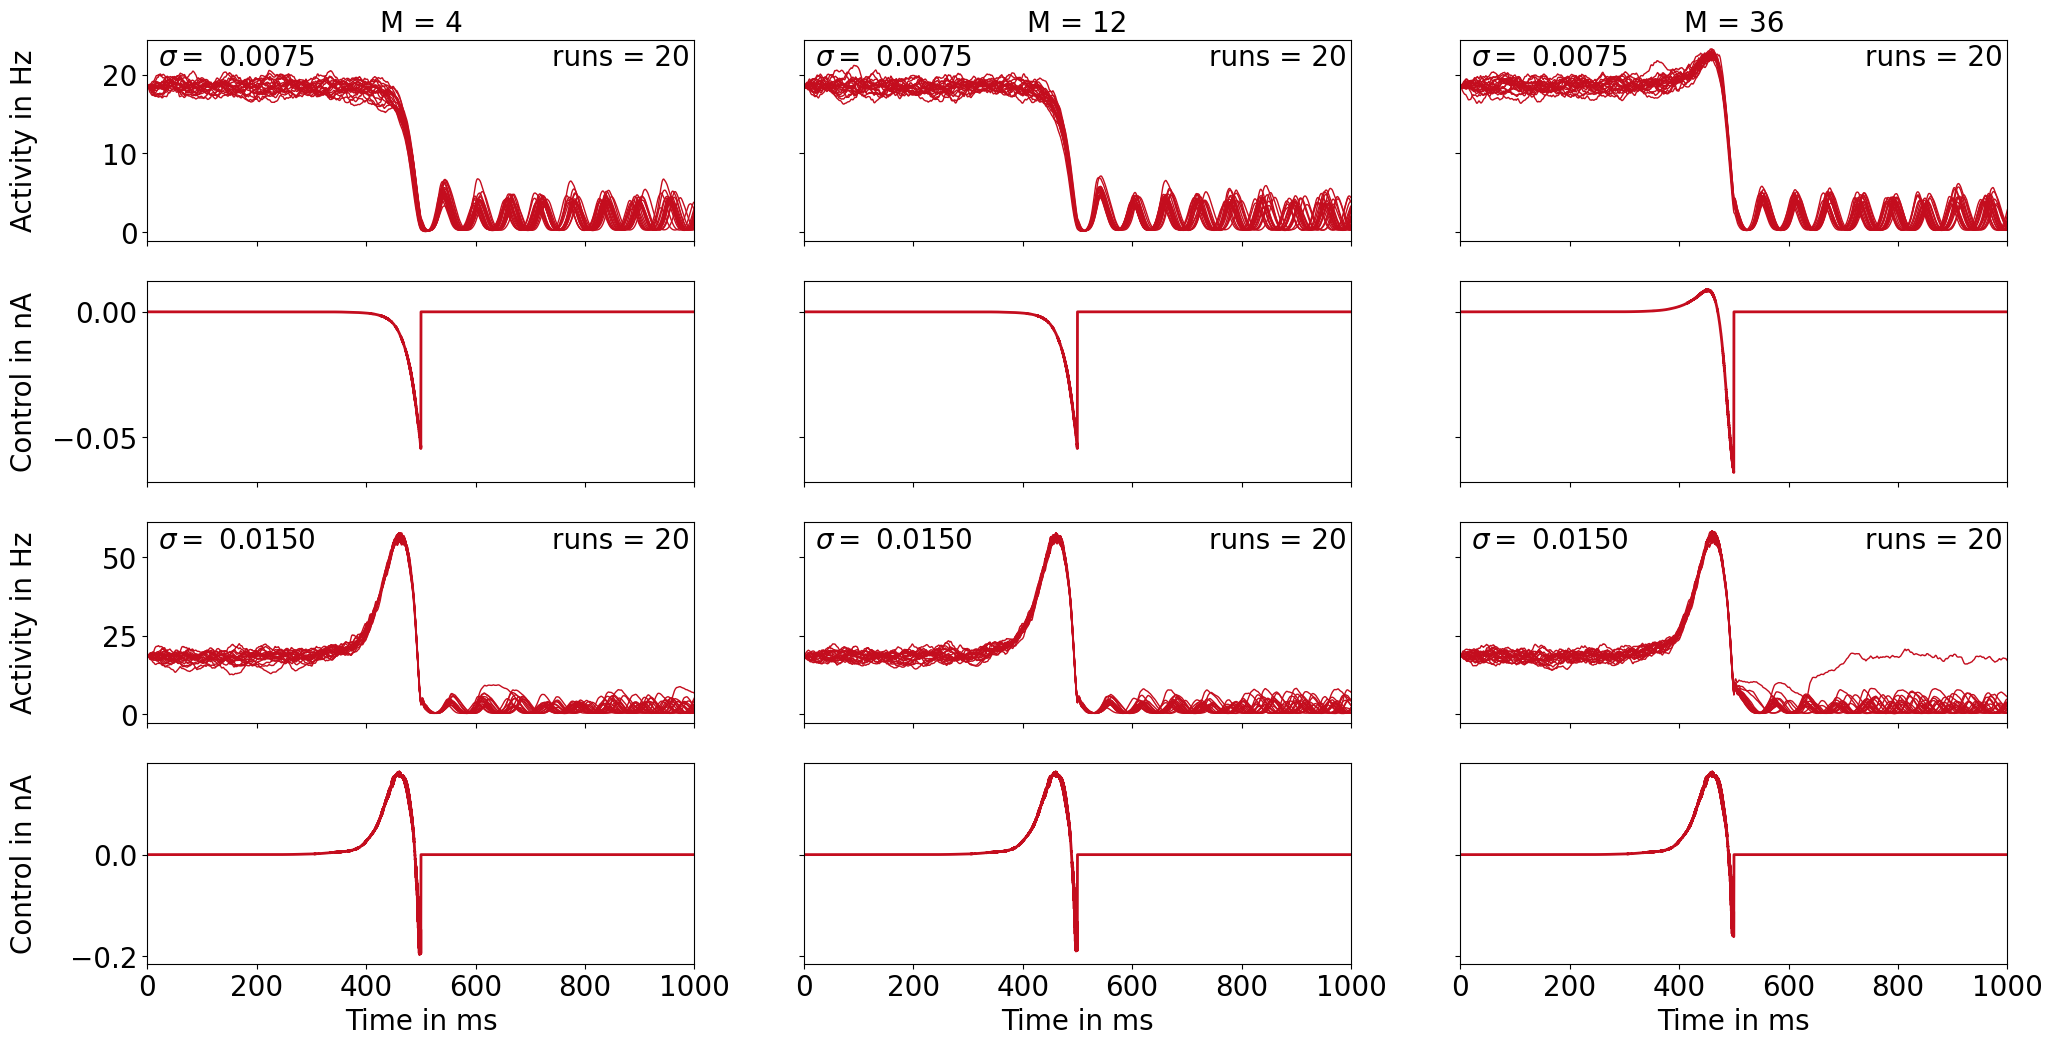

In [78]:
fig, ax = plt.subplots(4, 3, figsize=(24, 12), sharex=True, sharey="row")
time = np.arange(0, duration, dt)

for si, sigma in enumerate(sigma_array[:2]):
    print(sigma)
    for mi, m in enumerate(M_array):
        ci = 0
        aln = ALNModel()
        setinitstate(aln, data["init_state"][ci])
        aln.params["mue_ext_mean"] =  data["coordinates"][0]
        aln.params["mui_ext_mean"] =  data["coordinates"][1]
        aln.params.duration = duration
        aln.params["sigma_ou"] =  sigma

        aln.params["ext_exc_current"] = control_array[ci][si][mi][:,0,:]

        realizations = 20
        for k in range(realizations):
            aln.run()
            ax[2*si, mi].plot(time, aln.rates_exc[0,:], color="#c40d1e", linewidth=1)

        ax[2*si+1, mi].plot(time, 0.2*control_array[ci][si][mi][0,0,1:], color="#c40d1e", linewidth=2)

        ax[2*si, mi].text(0.02, 0.87, r"$\sigma =$ {:.4f}".format(sigma), transform=ax[2*si, mi].transAxes)
        ax[2*si, mi].text(0.74, 0.87, r"runs = {:.0f}".format(realizations), transform=ax[2*si, mi].transAxes)


for mi in range(len(M_array)):
    ax[0,mi].set_title("M = " + str(M_array[mi]))


ax[0,0].set_xlim(0,duration)
ax[0,0].set_ylabel("Activity in Hz")
ax[1,0].set_ylabel("Control in nA")
ax[2,0].set_ylabel("Activity in Hz")
ax[3,0].set_ylabel("Control in nA")
ax[3,0].set_xlabel("Time in ms")
ax[3,1].set_xlabel("Time in ms")
ax[3,2].set_xlabel("Time in ms")

ax[0,0].yaxis.set_label_coords(-0.2,.5)
ax[1,0].yaxis.set_label_coords(-0.2,.5)
ax[2,0].yaxis.set_label_coords(-0.2,.5)
ax[3,0].yaxis.set_label_coords(-0.2,.5)

plt.savefig("noise_ss_aln.pdf", bbox_inches='tight')

plt.show()
